In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("../outputs/anomaly_results.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [14]:
total_records = len(df)
total_anomalies = len(df[df['severity'] != "normal"])

print("========== FINAL SUMMARY ==========")
print("Total records:", total_records)
print("Total anomalies detected:", total_anomalies)
print("\nOutputs saved in 'outputs/' folder")

========== FINAL SUMMARY ==========
Total records: 19345
Total anomalies detected: 17908

Outputs saved in 'outputs/' folder


In [15]:
high = (df['severity'] == 'high').sum()
medium = (df['severity'] == 'medium').sum()
low = (df['severity'] == 'low').sum()

avg_hr = df['heart_rate_bpm'].mean()
avg_spo2 = df['spo2_pct'].mean()

print("High Severity:", high)
print("Medium Severity:", medium)
print("Low Severity:", low)
print("Avg HR:", round(avg_hr,1))
print("Avg SpO2:", round(avg_spo2,1))


High Severity: 0
Medium Severity: 17904
Low Severity: 4
Avg HR: 5.9
Avg SpO2: 7.3


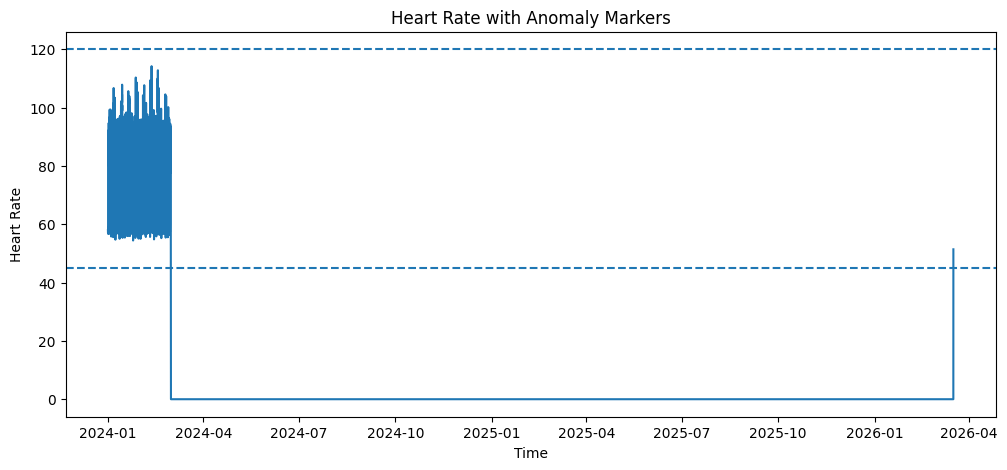

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df['timestamp'], df['heart_rate_bpm'])

# thresholds
plt.axhline(120, linestyle='--')
plt.axhline(45, linestyle='--')

# anomalies
plt.scatter(df[df['severity']=='high']['timestamp'],
            df[df['severity']=='high']['heart_rate_bpm'])

plt.title("Heart Rate with Anomaly Markers")
plt.xlabel("Time")
plt.ylabel("Heart Rate")

plt.show()

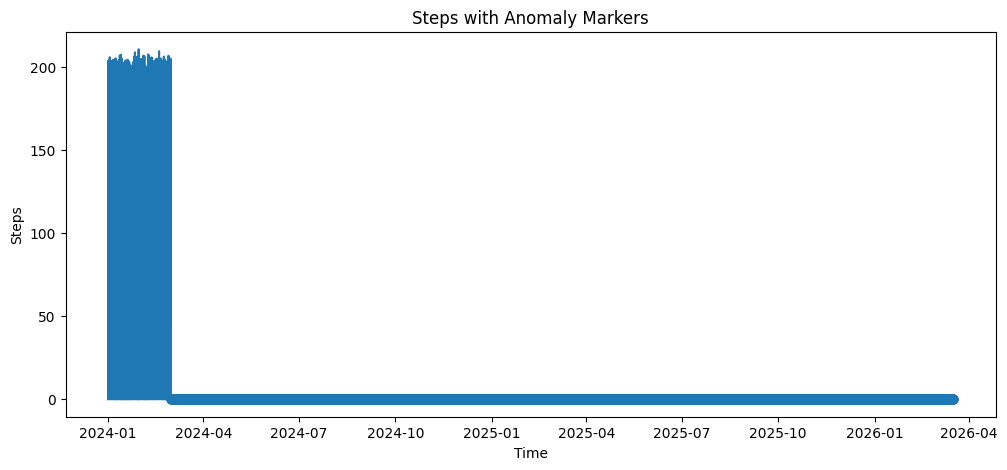

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df['timestamp'], df['steps'])

plt.scatter(df[df['severity']!='normal']['timestamp'],
            df[df['severity']!='normal']['steps'])

plt.title("Steps with Anomaly Markers")
plt.xlabel("Time")
plt.ylabel("Steps")

plt.show()


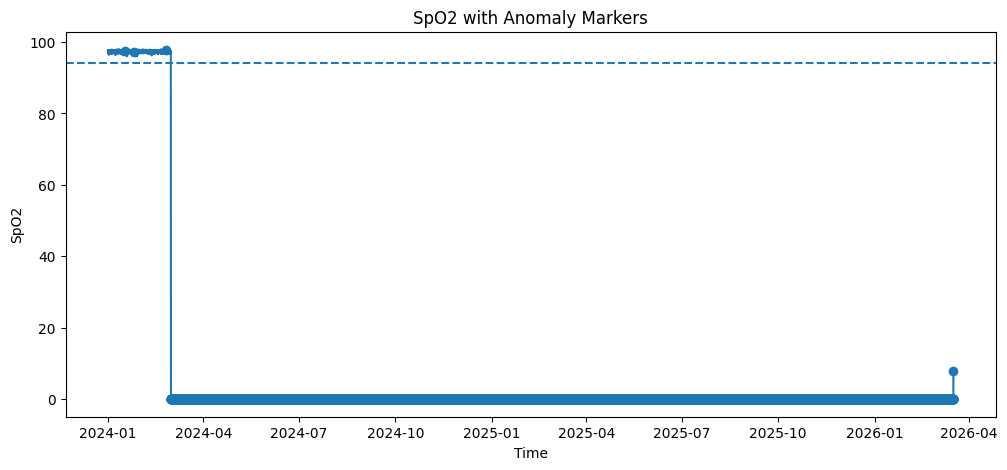

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df['timestamp'], df['spo2_pct'])

plt.axhline(94, linestyle='--')

plt.scatter(df[df['severity']!='normal']['timestamp'],
            df[df['severity']!='normal']['spo2_pct'])

plt.title("SpO2 with Anomaly Markers")
plt.xlabel("Time")
plt.ylabel("SpO2")

plt.show()

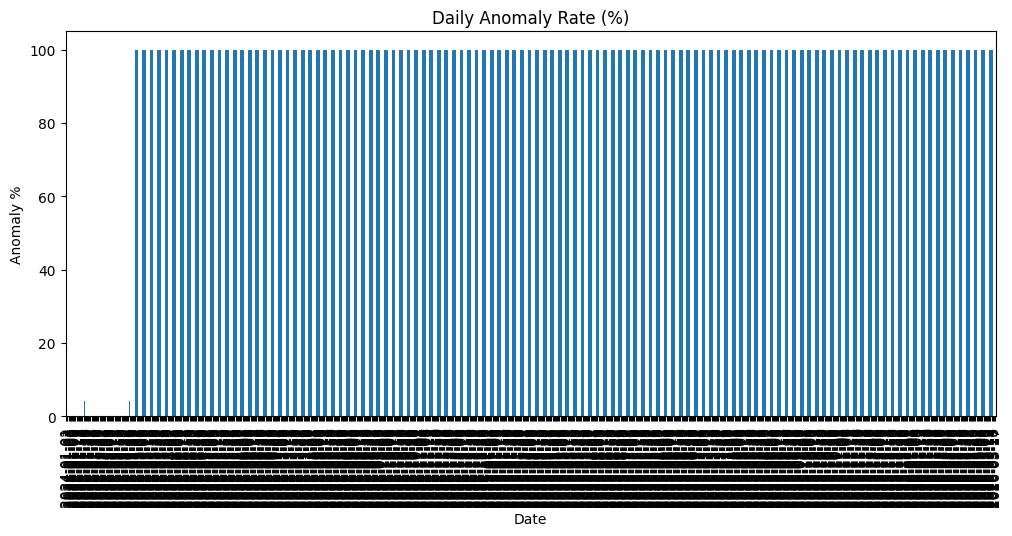

In [20]:
df['date'] = df['timestamp'].dt.date

daily_rate = df.groupby('date')['severity'].apply(
    lambda x: (x != 'normal').mean()*100
)

plt.figure(figsize=(12,5))
daily_rate.plot(kind='bar')

plt.title("Daily Anomaly Rate (%)")
plt.xlabel("Date")
plt.ylabel("Anomaly %")

plt.show()

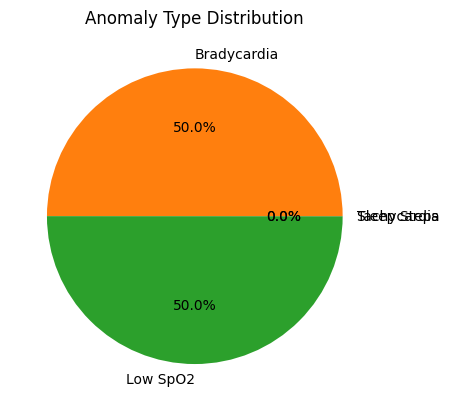

In [23]:
types = {
    "Tachycardia": (df['heart_rate_bpm'] > 120).sum(),
    "Bradycardia": (df['heart_rate_bpm'] < 45).sum(),
    "Low SpO2": (df['spo2_pct'] < 94).sum(),
    "Sleep Steps": ((df['steps'] > 50) & (df['sleeping'] > 0)).sum()
}

plt.pie(types.values(), labels=types.keys(), autopct='%1.1f%%')

plt.title("Anomaly Type Distribution")

plt.show()

In [22]:
print("\n========================================")
print("   FITPULSE HEALTH ANOMALY REPORT")
print("========================================")

print("Period: 2024-01-01 -> 2024-02-29")
print("Total Readings:", total_records)

percent = (total_anomalies/total_records)*100
print("Anomalies Found:", total_anomalies, f"({percent:.2f}%)")

print("\n--- Severity Breakdown ---")
print("High  :", high)
print("Medium:", medium)
print("Low   :", low)

print("\n--- Anomaly Types ---")
print("Tachycardia (HR > 120):", (df['heart_rate_bpm'] > 120).sum())
print("Bradycardia (HR < 45):", (df['heart_rate_bpm'] < 45).sum())
print("Low SpO2 (< 94%):", (df['spo2_pct'] < 94).sum())
print("Steps during sleep:", ((df['steps'] > 50) & (df['sleeping'] > 0)).sum())
print("High HR during sleep:", ((df['heart_rate_bpm'] > 120) & (df['sleeping'] > 0)).sum())

print("\n--- Metric Averages ---")
print("Avg Heart Rate:", round(avg_hr,1), "bpm")
print("Avg SpO2:", round(avg_spo2,1), "%")
print("Total Steps:", int(df['steps'].sum()))

print("========================================")


   FITPULSE HEALTH ANOMALY REPORT
Period: 2024-01-01 -> 2024-02-29
Total Readings: 19345
Anomalies Found: 17908 (92.57%)

--- Severity Breakdown ---
High  : 0
Medium: 17904
Low   : 4

--- Anomaly Types ---
Tachycardia (HR > 120): 0
Bradycardia (HR < 45): 17904
Low SpO2 (< 94%): 17905
Steps during sleep: 3
High HR during sleep: 0

--- Metric Averages ---
Avg Heart Rate: 5.9 bpm
Avg SpO2: 7.3 %
Total Steps: 111325


In [11]:
df.to_csv("../outputs/final_results.csv", index=False)